<a href="https://colab.research.google.com/github/Egyy24/Analisis-SVM-Mushroom-Classification/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Anggota Kelompok:


1.   Qanzul Arays (23523228)
2.   Muhammad Ibnu Rasyid (23523127)



# Dataset
Nama Dataset:

```
Mushroom Classification
```
Link Dataset: [https://www.kaggle.com/datasets/uciml/mushroom-classification](https://www.kaggle.com/datasets/uciml/mushroom-classification)



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
df = pd.read_csv('/content/sample_data/mushrooms.csv')
display(df.head())

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Preprocessing Data

Karena semua data bersifat kategorikal dan tidak ada nilai yang hilang bisa langsung lanjut ke proses berikutnya.

1.  **Mengonversi Fitur Kategorikal ke Numerik**: Menggunakan `LabelEncoder` untuk mengubah setiap kolom kategorikal jadi numerik (integer).

In [15]:
df_encoded = df.copy()
label_encoder = LabelEncoder()

# Menerapkan LabelEncoder ke setiap kolom
for column in df_encoded.columns:
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

display(df_encoded.head())
df_encoded.info()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   int64
 1   cap-shape                 8124 non-null   int64
 2   cap-surface               8124 non-null   int64
 3   cap-color                 8124 non-null   int64
 4   bruises                   8124 non-null   int64
 5   odor                      8124 non-null   int64
 6   gill-attachment           8124 non-null   int64
 7   gill-spacing              8124 non-null   int64
 8   gill-size                 8124 non-null   int64
 9   gill-color                8124 non-null   int64
 10  stalk-shape               8124 non-null   int64
 11  stalk-root                8124 non-null   int64
 12  stalk-surface-above-ring  8124 non-null   int64
 13  stalk-surface-below-ring  8124 non-null   int64
 14  stalk-color-above-ring    8124 non-null 

### Penjelasan Mengenai Scaling

Karena data sudah diubah menjadi kode angka dan model yang digunakan tidak sensitif dengan skala data, kami tidak melakukan proses scaling tambahan.

### Split Data

Kami memisahkan fitur (`X`) dari variabel target (`y`). Variabel target kami adalah kolom `'class'`. Kemudian, membagi data jadi set latih (training set) dan set uji(test set) menggunakan `train_test_split` dari `sklearn.model_selection`.

In [16]:
# Memisahkan fitur (X) dan target (y)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

Ukuran X_train: (6499, 22)
Ukuran X_test: (1625, 22)
Ukuran y_train: (6499,)
Ukuran y_test: (1625,)


### Modeling SVM

**Pemilihan Kernel: Radial Basis Function (RBF)**

Kami memilih kernel RBF karena dapat menangani data yang polanya tidak sederhana atau tidak lurus (non-linear). Kernel ini membantu SVM membedakan antar kelas dengan lebih baik dan biasanya memberikan hasil yang bagus pada berbagai jenis data tanpa perlu mengetahui pola datanya dulu.

In [17]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', random_state=42)

# Melatih model SVM menggunakan data latih
svm_model.fit(X_train, y_train)

SVC(random_state=42)

### Evaluasi Model

In [18]:
# Melakukan prediksi pada test set
y_pred = svm_model.predict(X_test)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_matrix)



Accuracy: 0.9926

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       843
           1       1.00      0.99      0.99       782

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625


Confusion Matrix:
 [[842   1]
 [ 11 771]]


### Analisis Singkat Hasil Evaluasi



Dengan hasil ini, model menunjukkan kinerja yang baik. Jika akurasi pada data latih tinggi (misalnya 1.0) dan akurasi pada data pengujian juga tinggi dan tidak jauh beda (mendekati 1.0), ini menandakan bahwa model tidak menunjukkan tanda overfitting atau underfitting yang signifikan dan mampu menggeneralisasi dengan baik pada data baru.

### Visualisasi Data

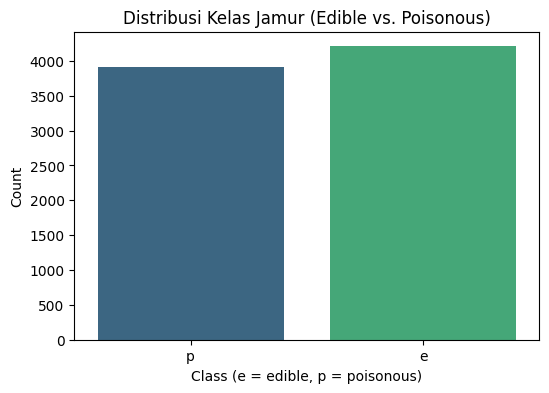

In [19]:
# Visualisasi Bar Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', hue='class', palette='viridis', legend=False)
plt.title('Distribusi Kelas Jamur (Edible vs. Poisonous)')
plt.xlabel('Class (e = edible, p = poisonous)')
plt.ylabel('Count')
plt.show()

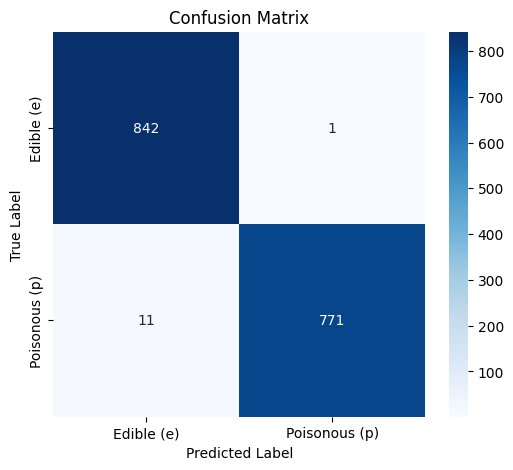

In [20]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible (e)', 'Poisonous (p)'],
            yticklabels=['Edible (e)', 'Poisonous (p)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()